In [1]:
import os
import numpy as np
import pandas as pd

PATH = '/kaggle/input/datasets/manushrivenkatesh/alibaba-cluster-dataset/machine_usage_bigger.csv'
WIN, STRIDE = 288, 144          # 288 steps = 1 day; slide half a day
GAP_LO, GAP_HI = 480, 520       # known interpolation-gap region to avoid
OUT_DIR = '/kaggle/working/traces'

In [ ]:
# 1. Load only the 2 columns
df = pd.read_csv(PATH, usecols=['time_stamp', 'cpu_util_percent'])
print("raw rows:", len(df))

raw rows: 95000000


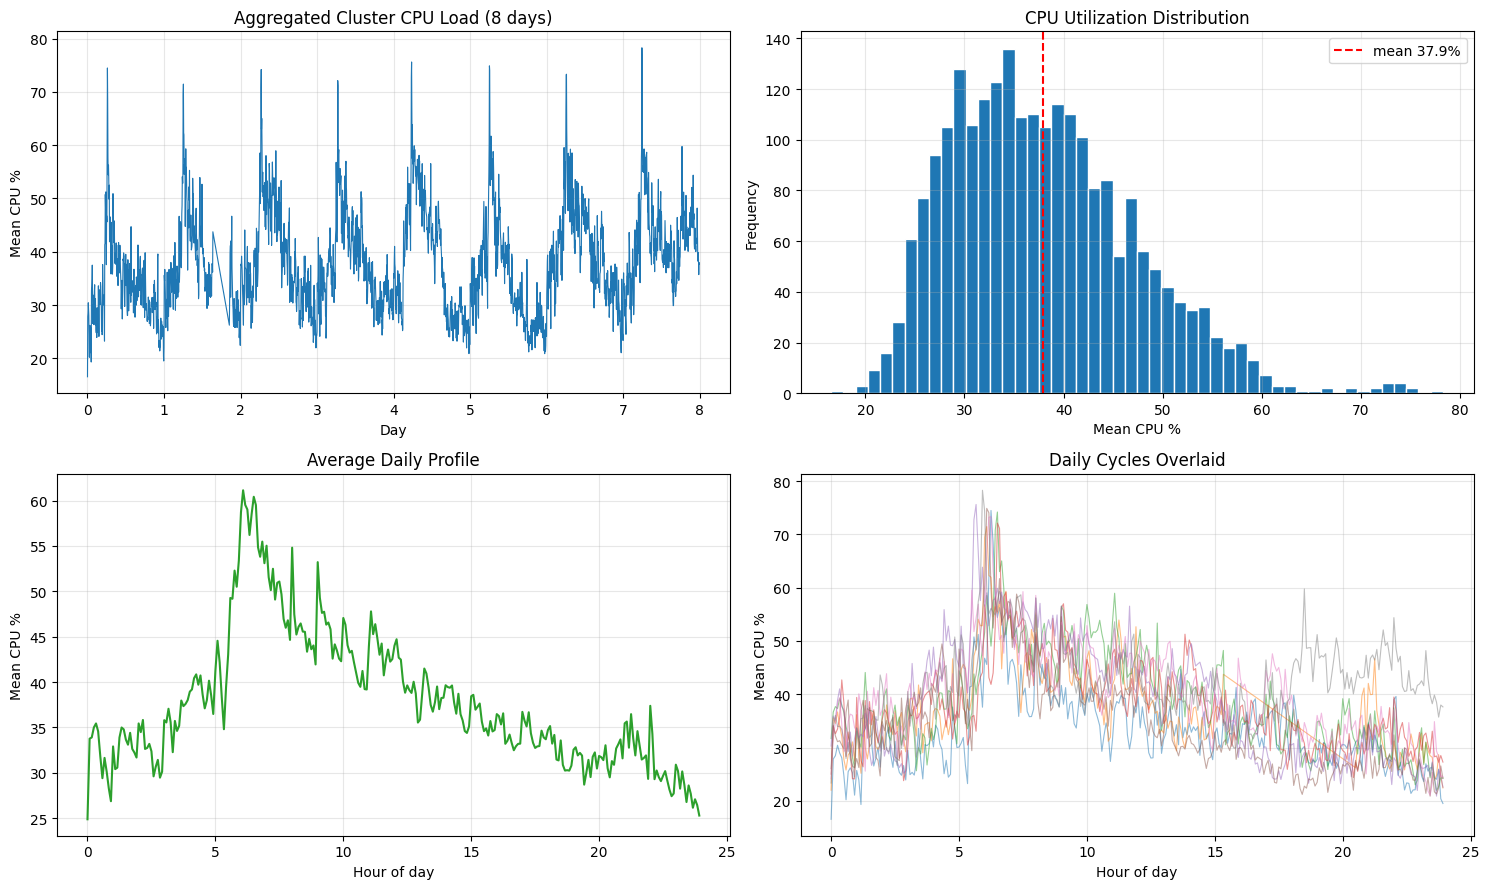

days: 8.0 | mean 37.9% | std 9.2 | min 16.5 | max 78.3


In [ ]:
import matplotlib.pyplot as plt

# rebuild if needed
if 'resampled' not in dir():
    load = df.groupby('time_stamp')['cpu_util_percent'].mean().sort_index()
    load.index = pd.to_timedelta(load.index, unit='s')
    resampled = load.resample('5min').mean().interpolate()

vals = resampled.values
days = np.arange(len(vals)) / 288.0   # x-axis in days

fig, ax = plt.subplots(2, 2, figsize=(15, 9))

# 1. Full 8-day load curve
ax[0,0].plot(days, vals, lw=0.8, color='#1f77b4')
ax[0,0].set(title='Aggregated Cluster CPU Load (8 days)', xlabel='Day', ylabel='Mean CPU %')
ax[0,0].grid(alpha=.3)

# 2. Distribution
ax[0,1].hist(vals, bins=50, color='#1f77b4', edgecolor='white')
ax[0,1].axvline(np.mean(vals), color='red', ls='--', label=f'mean {np.mean(vals):.1f}%')
ax[0,1].set(title='CPU Utilization Distribution', xlabel='Mean CPU %', ylabel='Frequency')
ax[0,1].legend(); ax[0,1].grid(alpha=.3)

# 3. Average daily profile (mean across the 8 days, per time-of-day)
n_days = len(vals) // 288
profile = vals[:n_days*288].reshape(n_days, 288).mean(axis=0)
hours = np.arange(288) * 5 / 60.0
ax[1,0].plot(hours, profile, color='#2ca02c')
ax[1,0].set(title='Average Daily Profile', xlabel='Hour of day', ylabel='Mean CPU %')
ax[1,0].grid(alpha=.3)

# 4. Per-day overlay (see consistency of the cycle)
for d in range(n_days):
    ax[1,1].plot(hours, vals[d*288:(d+1)*288], alpha=.5, lw=.8)
ax[1,1].set(title='Daily Cycles Overlaid', xlabel='Hour of day', ylabel='Mean CPU %')
ax[1,1].grid(alpha=.3)

plt.tight_layout()
plt.savefig('/kaggle/working/eda_load.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"days: {len(vals)/288:.1f} | mean {np.mean(vals):.1f}% | std {np.std(vals):.1f} | min {vals.min():.1f} | max {vals.max():.1f}")

In [3]:
# 2. Aggregate: mean CPU across all machines per timestamp
load = df.groupby('time_stamp')['cpu_util_percent'].mean().sort_index()
print("distinct timestamps:", len(load))

distinct timestamps: 67241


In [4]:
# 3. Resample to uniform 5-min grid + fill gaps
load.index = pd.to_timedelta(load.index, unit='s')
series = load.resample('5min').mean().interpolate()
norm = np.clip(series.values / 100.0, 0, 1).astype(np.float32)
print("resampled length:", len(norm), "| min", round(float(norm.min()),3), "| max", round(float(norm.max()),3))

resampled length: 2304 | min 0.165 | max 0.783


In [5]:

# 4. Slide windows, skipping the gap region
slices = []
for start in range(0, len(norm) - WIN + 1, STRIDE):
    if start <= GAP_HI and start + WIN >= GAP_LO:   # window touches gap -> skip
        continue
    slices.append(norm[start:start + WIN])
print("usable traces:", len(slices))

usable traces: 13


In [6]:
# 5. Save each trace
os.makedirs(OUT_DIR, exist_ok=True)
for i, w in enumerate(slices):
    np.save(f'{OUT_DIR}/trace_{i:02d}.npy', w)
print(f"saved {len(slices)} traces to {OUT_DIR}/")

saved 13 traces to /kaggle/working/traces/


In [7]:
import shutil
shutil.make_archive('/kaggle/working/traces', 'zip', '/kaggle/working/traces')
print("created /kaggle/working/traces.zip")

created /kaggle/working/traces.zip
